# Model Evaluation and Inference - Nepali News Classification

This notebook evaluates the trained model on the test set and demonstrates how to use it for inference on new text samples.

## Objectives:
1. Load the trained model from checkpoint
2. Load test dataset
3. Evaluate model performance on test set
4. Generate detailed metrics (accuracy, F1 scores, per-class metrics)
5. Create confusion matrix and classification report
6. Visualize evaluation results
7. **Perform inference on individual and batch text samples**
8. Save evaluation results


In [1]:
# Import required libraries
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    classification_report, 
    confusion_matrix,
    precision_score,
    recall_score
)

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

# Import custom modules
try:
    from model import create_model, NepaliNewsClassifier
    from transformers import XLMRobertaTokenizer
    print("✓ Custom modules imported successfully")
except ImportError as e:
    print(f"✗ Error importing custom modules: {e}")
    raise

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")
if torch.cuda.is_available():
    print(f"✓ CUDA Device: {torch.cuda.get_device_name(0)}")
print(f"✓ PyTorch version: {torch.__version__}")


✓ Custom modules imported successfully
✓ Using device: cuda
✓ CUDA Device: NVIDIA GeForce RTX 2050
✓ PyTorch version: 2.5.1+cu121


## 1. Load Model Configuration and Checkpoint


In [2]:
# Load model configuration from training summary
models_dir = project_root / 'models'
summary_path = models_dir / 'training_summary.json'

if summary_path.exists():
    with open(summary_path, 'r', encoding='utf-8') as f:
        summary = json.load(f)
    
    MODEL_NAME = summary['model_name']
    NUM_CLASSES = summary['num_classes']
    print(f"✓ Loaded model configuration:")
    print(f"  Model: {MODEL_NAME}")
    print(f"  Classes: {NUM_CLASSES}")
    print(f"  Best Validation F1 (weighted): {summary['best_val_f1_weighted']:.4f}")
    print(f"  Best Validation Accuracy: {summary['best_val_accuracy']:.4f}")
else:
    # Default configuration if summary not found
    MODEL_NAME = 'xlm-roberta-base'
    NUM_CLASSES = 20
    print("⚠ Training summary not found, using default configuration")

MAX_LENGTH = 512
DROPOUT_RATE = 0.3

# Load model checkpoint
checkpoint_path = models_dir / 'best_model.pt'
if not checkpoint_path.exists():
    checkpoint_path = models_dir / 'final_model.pt'

if checkpoint_path.exists():
    print(f"\n✓ Loading model from: {checkpoint_path.name}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Get model configuration from checkpoint if available
    if 'model_name' in checkpoint:
        MODEL_NAME = checkpoint['model_name']
    if 'num_classes' in checkpoint:
        NUM_CLASSES = checkpoint['num_classes']
    if 'dropout_rate' in checkpoint:
        DROPOUT_RATE = checkpoint['dropout_rate']
    if 'max_length' in checkpoint:
        MAX_LENGTH = checkpoint['max_length']
    
    print(f"  Model: {MODEL_NAME}")
    print(f"  Classes: {NUM_CLASSES}")
    print(f"  Epoch: {checkpoint.get('epoch', 'N/A')}")
    if 'val_f1_weighted' in checkpoint:
        print(f"  Validation F1 (weighted): {checkpoint['val_f1_weighted']:.4f}")
else:
    raise FileNotFoundError(f"Model checkpoint not found at {checkpoint_path}")


✓ Loaded model configuration:
  Model: xlm-roberta-base
  Classes: 20
  Best Validation F1 (weighted): 0.7252
  Best Validation Accuracy: 0.7081

✓ Loading model from: best_model.pt
  Model: xlm-roberta-base
  Classes: 20
  Epoch: 9
  Validation F1 (weighted): 0.7252


## 2. Initialize Tokenizer and Load Model


In [3]:
# Initialize tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = XLMRobertaTokenizer.from_pretrained(MODEL_NAME)
print("✓ Tokenizer loaded")

# Create model
print(f"\nCreating model: {MODEL_NAME}")
model = create_model(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE,
    device=device
)

# Load model weights
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()  # Set to evaluation mode

print(f"✓ Model loaded and moved to {device}")
print(f"✓ Model in evaluation mode")


Loading tokenizer: xlm-roberta-base
✓ Tokenizer loaded

Creating model: xlm-roberta-base
✓ Model loaded and moved to cuda
✓ Model in evaluation mode


## 3. Load Test Dataset and Label Mappings


In [4]:
# Load test dataset
data_dir = project_root / 'data' / 'splits'
test_df = pd.read_csv(data_dir / 'test.csv')

print(f"✓ Test samples: {len(test_df):,}")

# Display sample
print("\nSample test data:")
print(test_df.head(3))

# Check label distribution
print("\nTest label distribution:")
print(test_df['category_id'].value_counts().sort_index())

# Load label mappings
label_mappings_path = project_root / 'data' / 'processed' / 'label_mappings.json'
with open(label_mappings_path, 'r', encoding='utf-8') as f:
    label_mappings = json.load(f)

id_to_label = {int(k): v for k, v in label_mappings['id_to_label'].items()}
label_to_id = {v: int(k) for k, v in label_mappings['id_to_label'].items()}

print(f"\n✓ Loaded label mappings")
print(f"Total categories: {len(id_to_label)}")
print(f"Sample labels: {[id_to_label[i] for i in range(5)]}")


✓ Test samples: 1,046

Sample test data:
                                                text category  category_id  \
0                         ÿþ$ M 0 ? 6 B 2 @   2 M  @     Bank            2   
1  ﻿नेपाल र लाओसविरूद्ध एएफसी सोलिडारिटी कपको सेम...   Sports           16   
2                                         ÿþ8 H ( ?     World           19   

                                           file_path  text_length_after  
0  D:\MSc Islington\NEural Networks and Deep Lear...                 26  
1  D:\MSc Islington\NEural Networks and Deep Lear...                492  
2  D:\MSc Islington\NEural Networks and Deep Lear...                 10  

Test label distribution:
category_id
0     30
1     37
2     93
3     39
4     46
5     90
6     28
7     45
8     95
9     27
10    50
11    37
12    16
13    75
14    83
15    53
16    98
17    17
18    40
19    47
Name: count, dtype: int64

✓ Loaded label mappings
Total categories: 20
Sample labels: ['Agriculture', 'Automobiles', 'Bank', 'Blog'

## 4. Create Dataset and DataLoader for Test Set


In [5]:
class NepaliNewsDataset(Dataset):
    """Dataset class for Nepali news articles"""
    
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create test dataset
print("Creating test dataset...")
test_dataset = NepaliNewsDataset(
    texts=test_df['text'].tolist(),
    labels=test_df['category_id'].tolist(),
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

print(f"✓ Test dataset: {len(test_dataset)} samples")

# Create data loader
BATCH_SIZE = 16
NUM_WORKERS = 0  # Set to 0 for Windows compatibility

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"✓ Test data loader created")
print(f"Test batches: {len(test_loader)}")


Creating test dataset...
✓ Test dataset: 1046 samples
✓ Test data loader created
Test batches: 66


## 5. Evaluate Model on Test Set


In [6]:
# Evaluate on test set
print("Evaluating model on test set...")
all_predictions = []
all_labels = []
all_probs = []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        
        # Get predictions and probabilities
        probs = torch.softmax(logits, dim=-1)
        predictions = torch.argmax(logits, dim=-1).cpu().numpy()
        
        all_predictions.extend(predictions)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print("✓ Evaluation complete")

# Calculate overall metrics
accuracy = accuracy_score(all_labels, all_predictions)
f1_weighted = f1_score(all_labels, all_predictions, average='weighted')
f1_macro = f1_score(all_labels, all_predictions, average='macro')
precision_weighted = precision_score(all_labels, all_predictions, average='weighted')
precision_macro = precision_score(all_labels, all_predictions, average='macro')
recall_weighted = recall_score(all_labels, all_predictions, average='weighted')
recall_macro = recall_score(all_labels, all_predictions, average='macro')

print("\n" + "=" * 80)
print("TEST SET EVALUATION RESULTS")
print("=" * 80)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"\nWeighted Average Metrics:")
print(f"  Precision: {precision_weighted:.4f}")
print(f"  Recall:    {recall_weighted:.4f}")
print(f"  F1 Score:  {f1_weighted:.4f}")
print(f"\nMacro Average Metrics:")
print(f"  Precision: {precision_macro:.4f}")
print(f"  Recall:    {recall_macro:.4f}")
print(f"  F1 Score:  {f1_macro:.4f}")
print("=" * 80)


Evaluating model on test set...


Evaluating: 100%|██████████| 66/66 [12:50<00:00, 11.67s/it]

✓ Evaluation complete

TEST SET EVALUATION RESULTS
Accuracy: 0.6989 (69.89%)

Weighted Average Metrics:
  Precision: 0.7565
  Recall:    0.6989
  F1 Score:  0.7136

Macro Average Metrics:
  Precision: 0.7303
  Recall:    0.6845
  F1 Score:  0.6843


## 6. Per-Class Classification Report


In [7]:
# Generate detailed classification report
target_names = [id_to_label[i] for i in range(NUM_CLASSES)]

print("\n" + "=" * 80)
print("PER-CLASS CLASSIFICATION REPORT")
print("=" * 80)
print(classification_report(
    all_labels, 
    all_predictions, 
    target_names=target_names, 
    digits=4
))
print("=" * 80)

# Calculate per-class metrics
from collections import defaultdict
per_class_metrics = defaultdict(dict)

for i in range(NUM_CLASSES):
    class_mask = np.array(all_labels) == i
    if class_mask.sum() > 0:  # Only if class exists in test set
        class_predictions = np.array(all_predictions)[class_mask]
        class_labels = np.array(all_labels)[class_mask]
        
        # Calculate per-class metrics correctly
        # For binary classification per class, we need to compare each class vs all others
        binary_labels = (class_labels == i).astype(int)
        binary_predictions = (class_predictions == i).astype(int)
        
        # Calculate metrics with zero_division handling
        tp = np.sum((binary_labels == 1) & (binary_predictions == 1))
        fp = np.sum((binary_labels == 0) & (binary_predictions == 1))
        fn = np.sum((binary_labels == 1) & (binary_predictions == 0))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
        per_class_metrics[i] = {
            'label': id_to_label[i],
            'support': int(class_mask.sum()),
            'precision': float(precision),
            'recall': float(recall),
            'f1': float(f1)
        }

# Display per-class metrics in a table
print("\nPer-Class Metrics Summary:")
print("-" * 100)
print(f"{'Class':<20} {'Label':<25} {'Support':<10} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 100)
for i in range(NUM_CLASSES):
    if i in per_class_metrics:
        metrics = per_class_metrics[i]
        print(f"{i:<20} {metrics['label']:<25} {metrics['support']:<10} "
              f"{metrics['precision']:<12.4f} {metrics['recall']:<12.4f} {metrics['f1']:<12.4f}")
print("-" * 100)



PER-CLASS CLASSIFICATION REPORT
               precision    recall  f1-score   support

  Agriculture     0.3962    0.7000    0.5060        30
  Automobiles     0.9500    0.5135    0.6667        37
         Bank     0.6970    0.7419    0.7188        93
         Blog     0.7391    0.8718    0.8000        39
     Business     0.5455    0.2609    0.3529        46
      Economy     0.7333    0.6111    0.6667        90
    Education     0.8519    0.8214    0.8364        28
   Employment     0.6977    0.6667    0.6818        45
Entertainment     0.8452    0.7474    0.7933        95
       Health     0.1552    0.6667    0.2517        27
    Interview     0.4595    0.3400    0.3908        50
   Literature     0.8824    0.8108    0.8451        37
    Migration     0.8000    1.0000    0.8889        16
      Opinion     0.9104    0.8133    0.8592        75
     Politics     0.9759    0.9759    0.9759        83
      Society     0.5745    0.5094    0.5400        53
       Sports     0.8681    0.8

## 7. Confusion Matrix


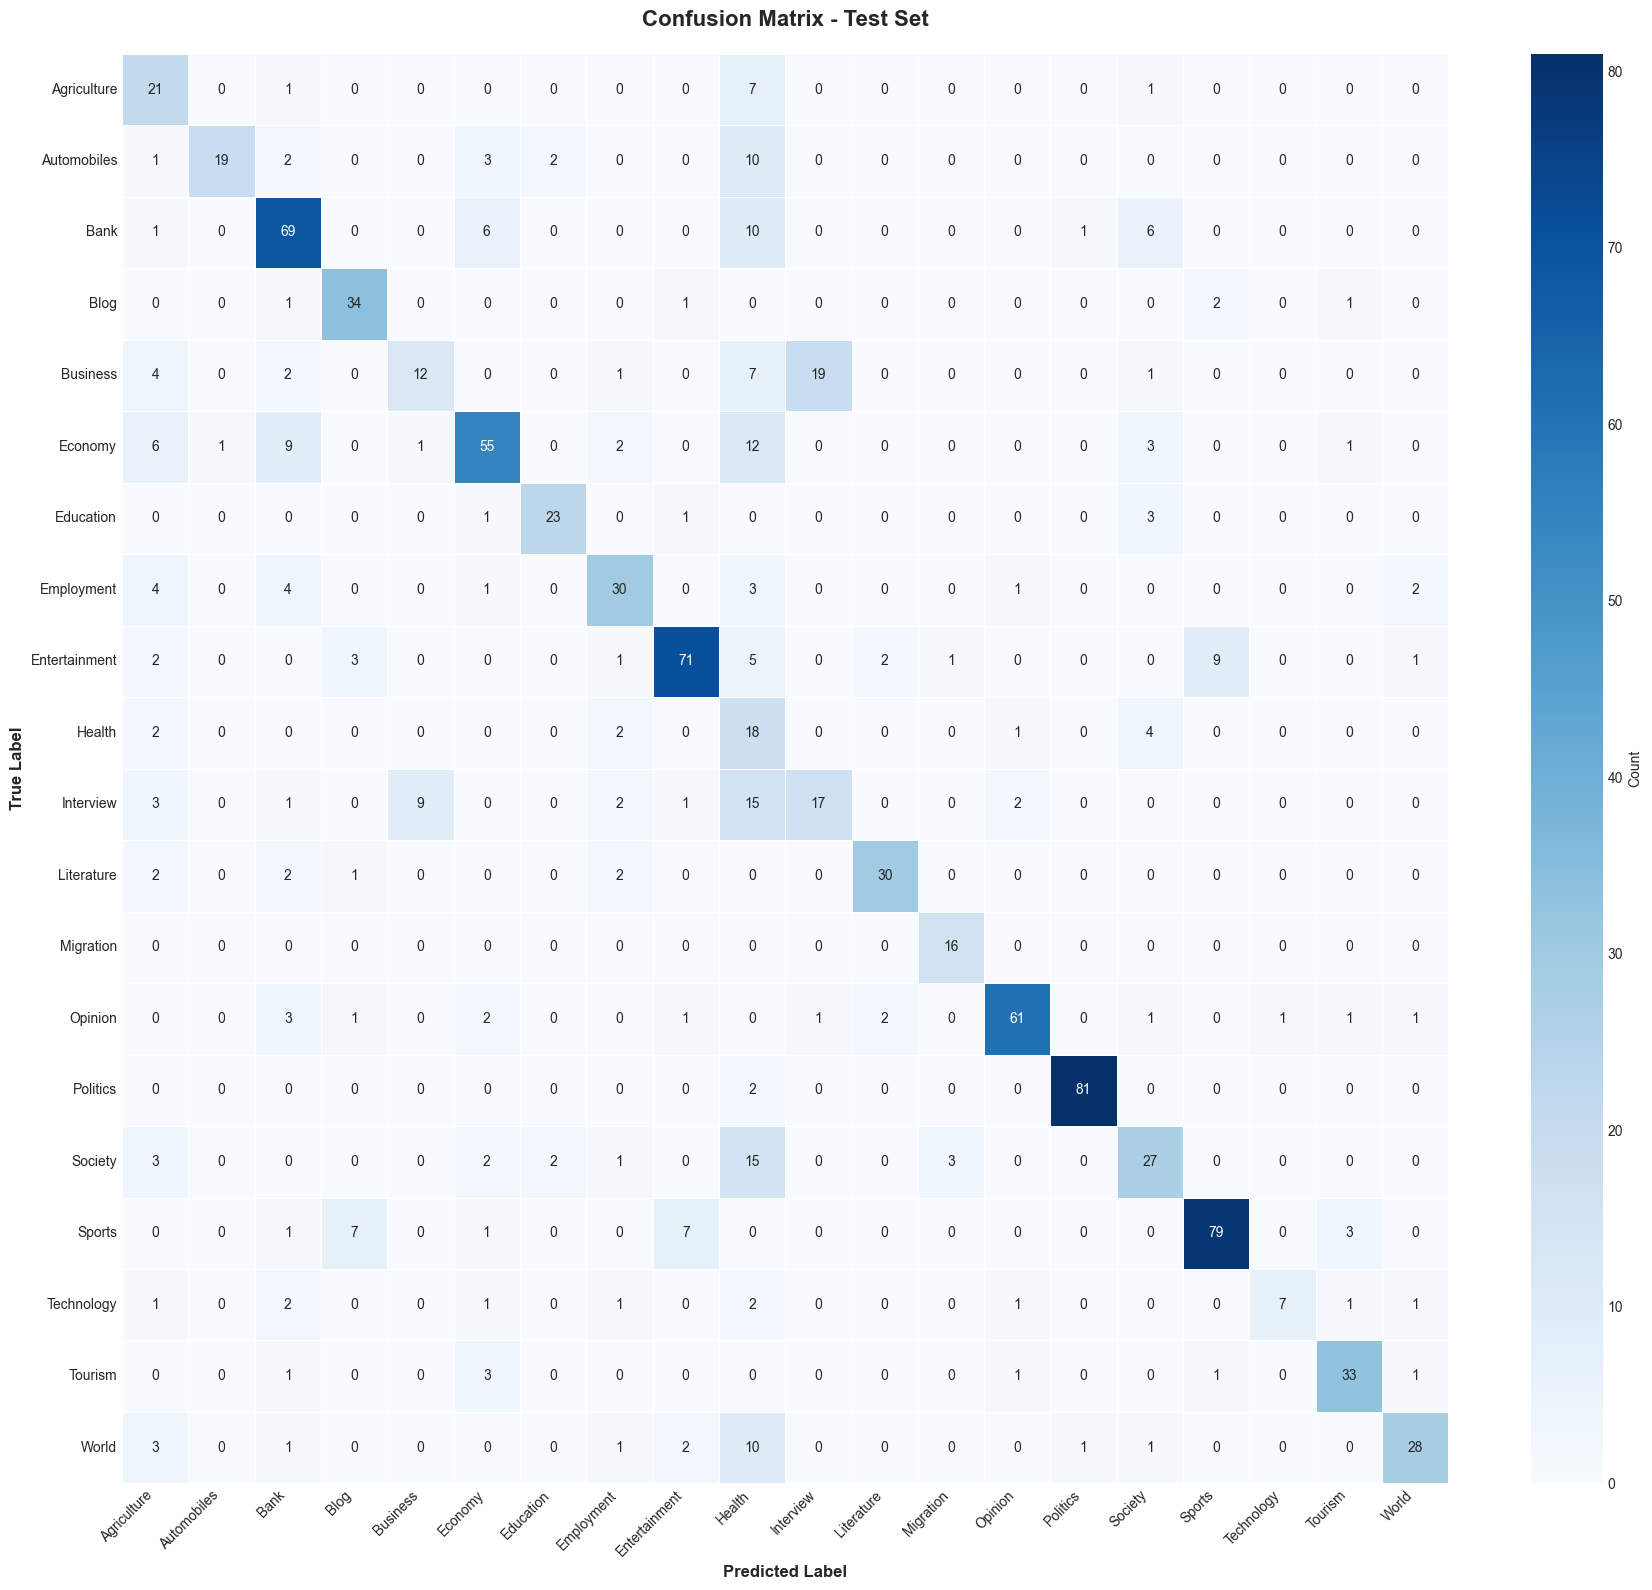

✓ Confusion matrix saved


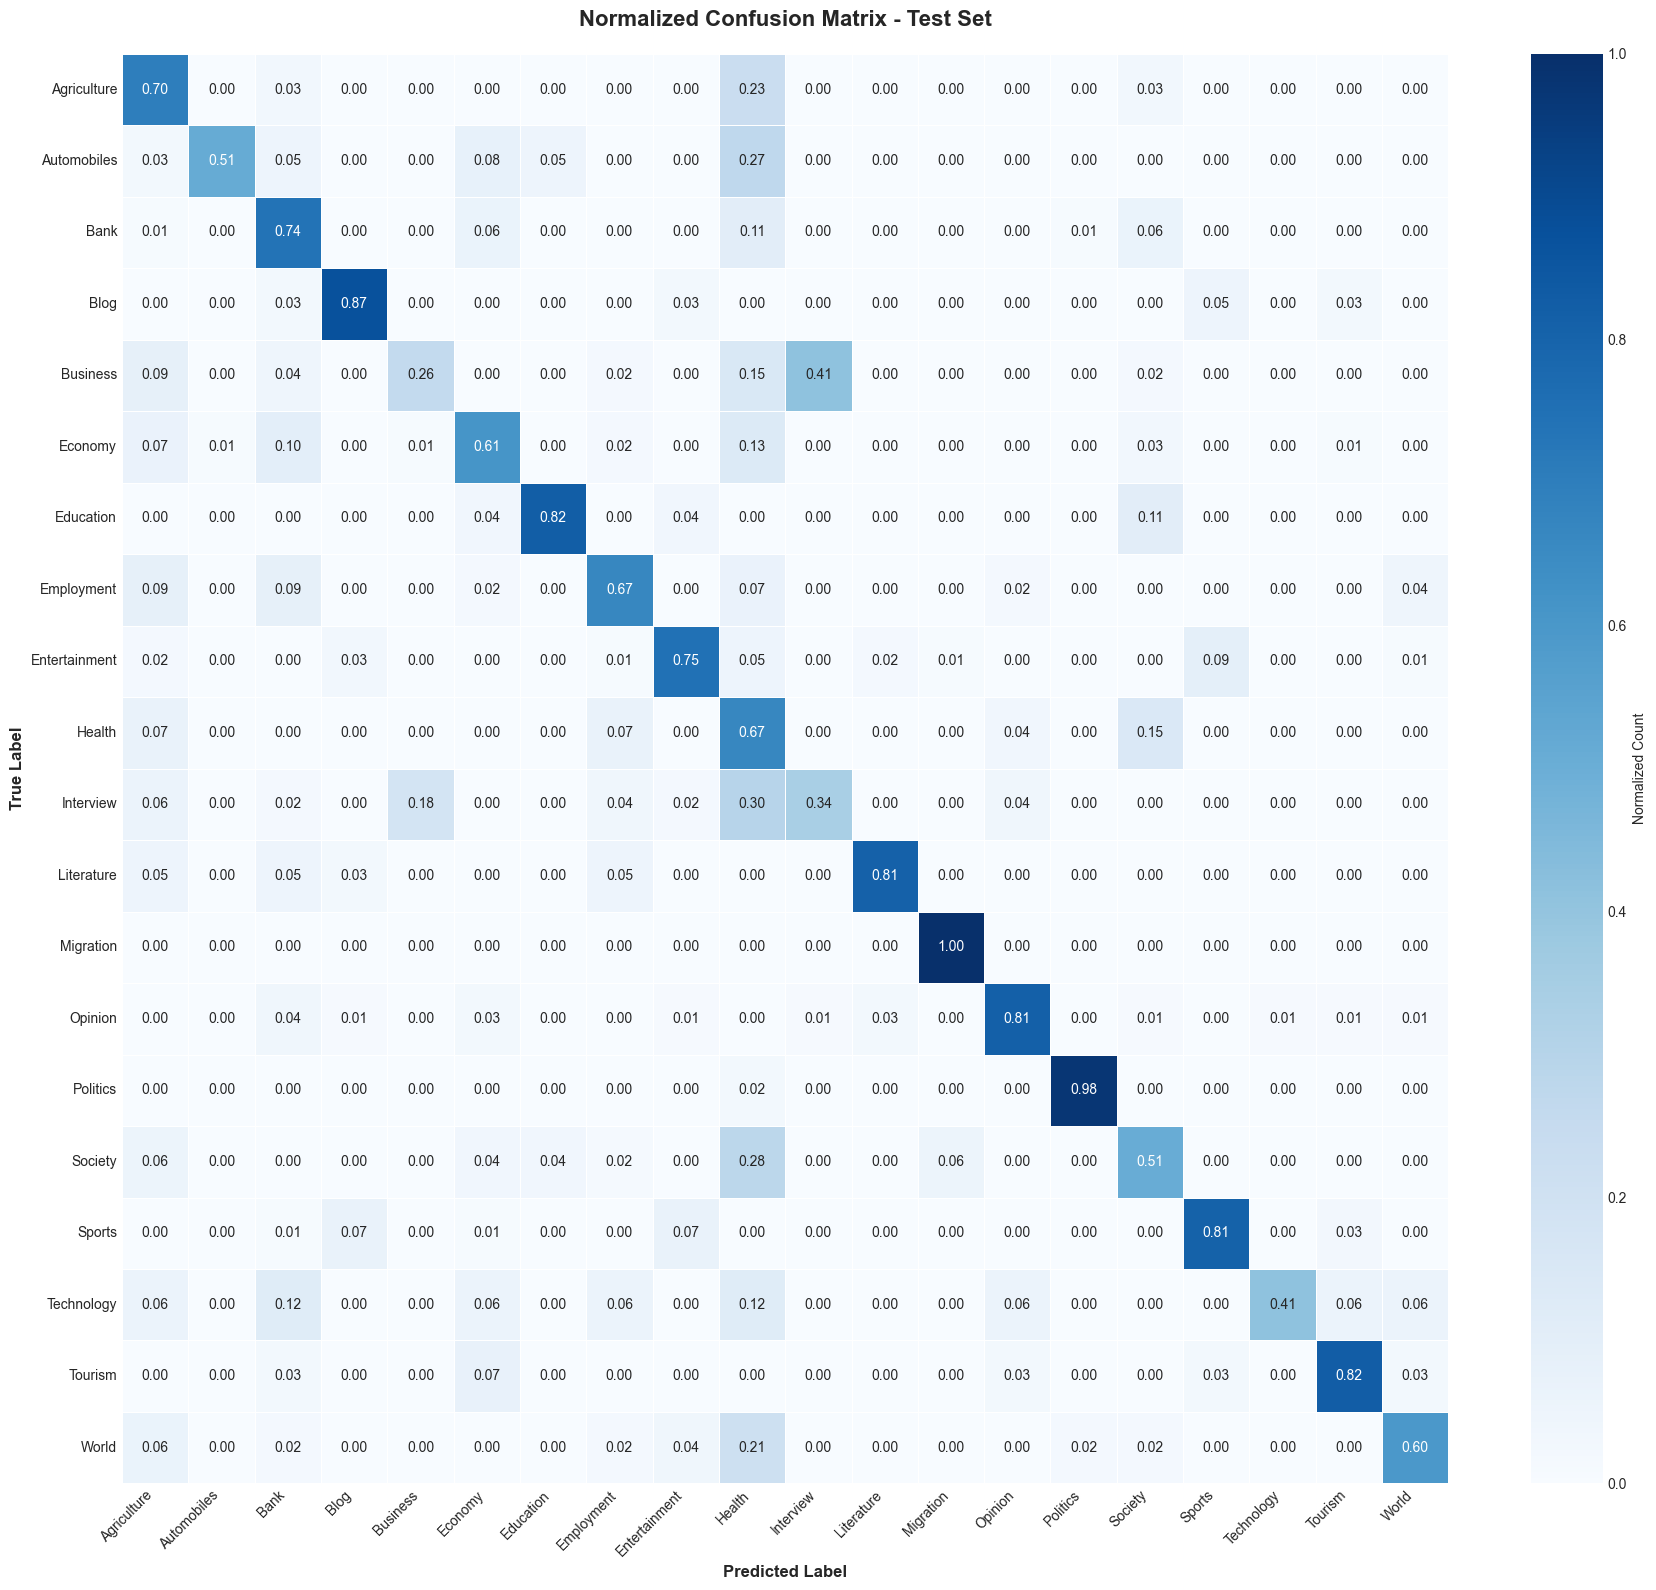

✓ Normalized confusion matrix saved


In [8]:
# Generate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Create visualization directory
viz_dir = project_root / 'results' / 'visualizations'
viz_dir.mkdir(parents=True, exist_ok=True)

# Plot confusion matrix
plt.figure(figsize=(18, 16))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[id_to_label[i] for i in range(NUM_CLASSES)],
    yticklabels=[id_to_label[i] for i in range(NUM_CLASSES)],
    cbar_kws={'label': 'Count'},
    linewidths=0.5
)
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(viz_dir / 'confusion_matrix_test.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved")

# Calculate normalized confusion matrix for better visualization
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_normalized = np.nan_to_num(cm_normalized)  # Handle division by zero

plt.figure(figsize=(18, 16))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=[id_to_label[i] for i in range(NUM_CLASSES)],
    yticklabels=[id_to_label[i] for i in range(NUM_CLASSES)],
    cbar_kws={'label': 'Normalized Count'},
    linewidths=0.5
)
plt.title('Normalized Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(viz_dir / 'confusion_matrix_test_normalized.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Normalized confusion matrix saved")


## 8. Per-Class Performance Visualization


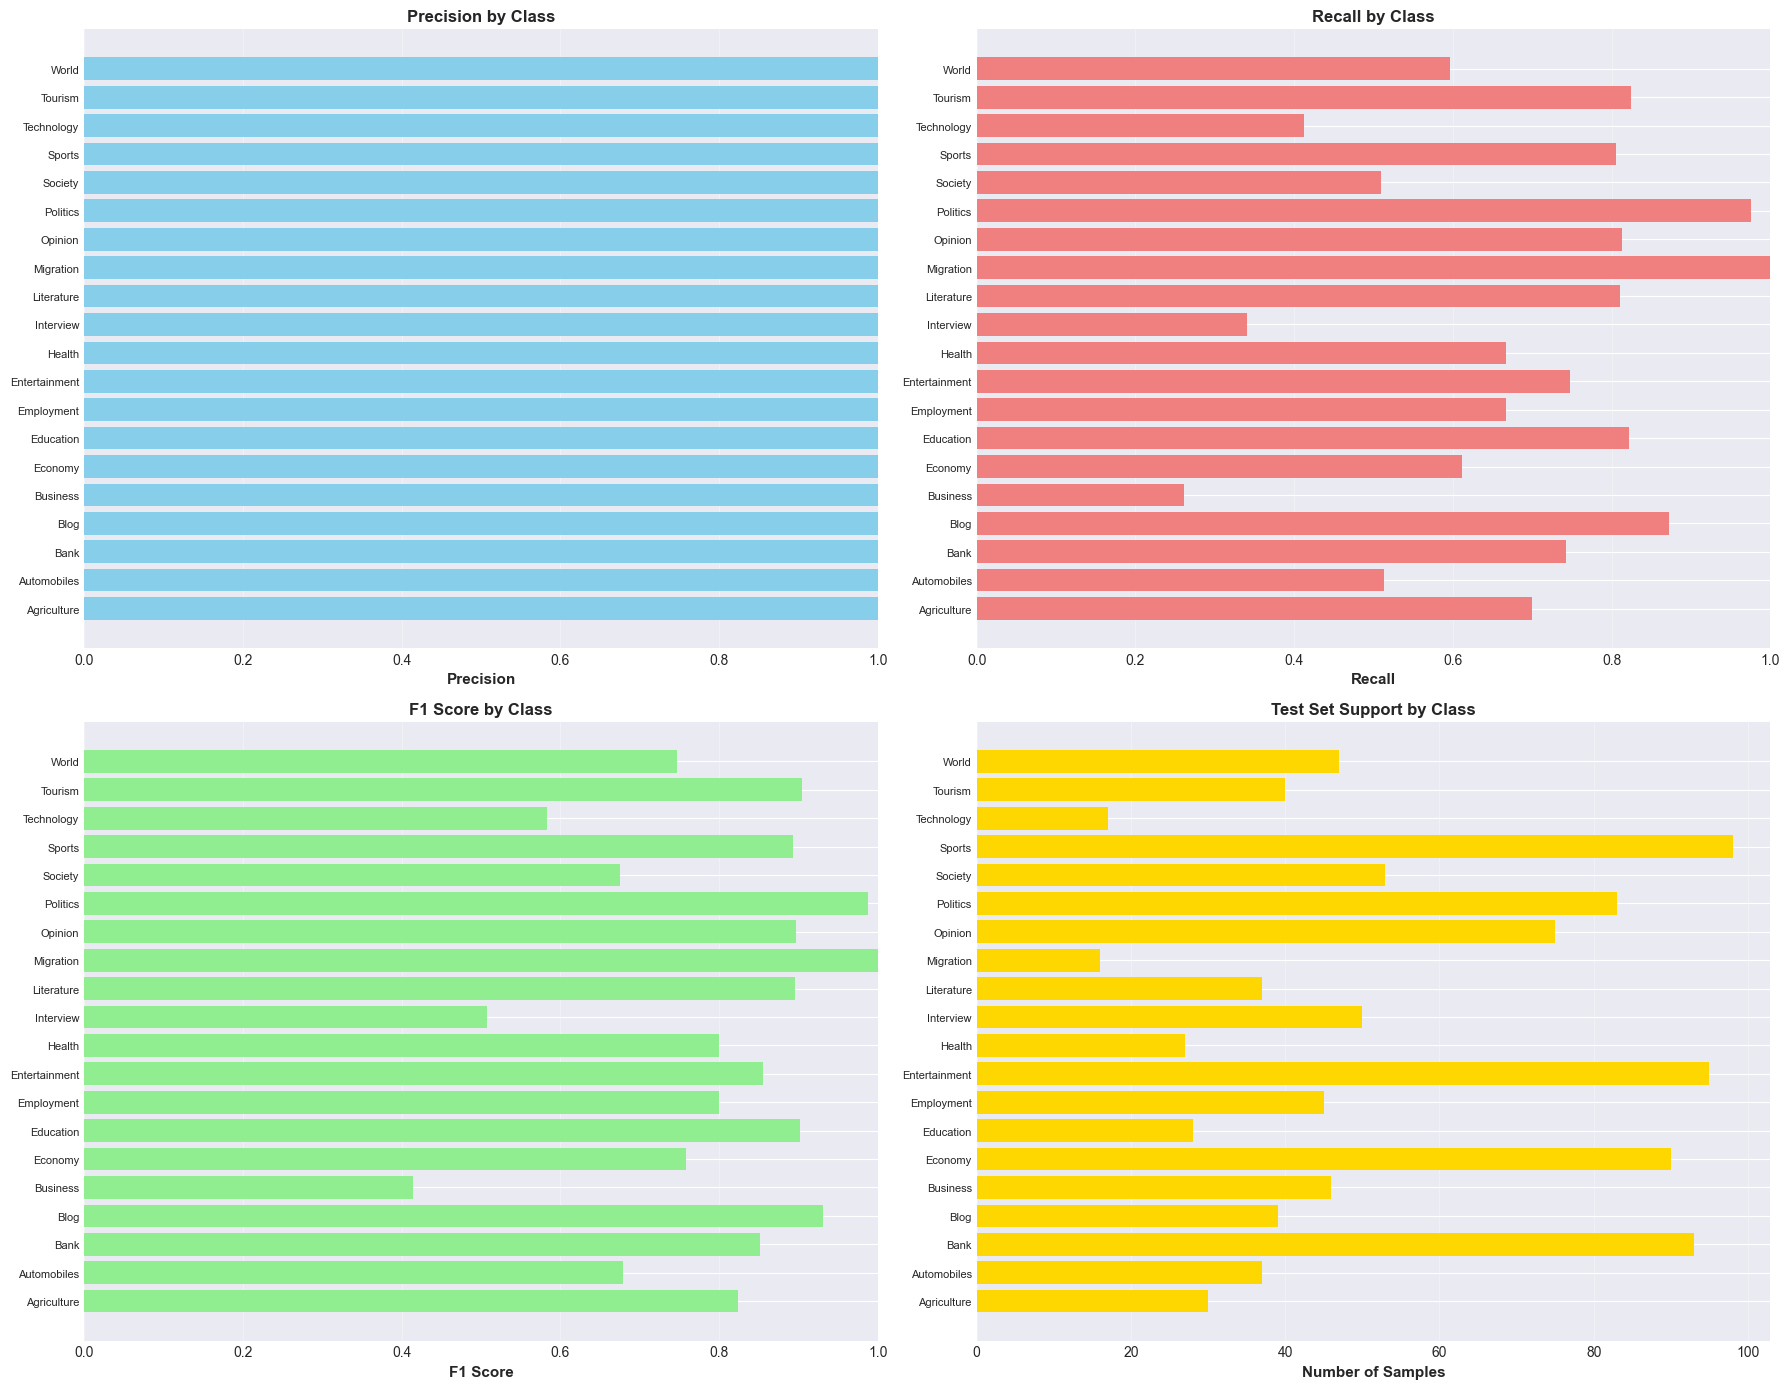

✓ Per-class metrics visualization saved


In [9]:
# Create per-class metrics visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Extract metrics
class_ids = sorted(per_class_metrics.keys())
class_labels_list = [per_class_metrics[i]['label'] for i in class_ids]
precisions = [per_class_metrics[i]['precision'] for i in class_ids]
recalls = [per_class_metrics[i]['recall'] for i in class_ids]
f1_scores = [per_class_metrics[i]['f1'] for i in class_ids]
supports = [per_class_metrics[i]['support'] for i in class_ids]

# Precision by class
axes[0, 0].barh(range(len(class_ids)), precisions, color='skyblue')
axes[0, 0].set_yticks(range(len(class_ids)))
axes[0, 0].set_yticklabels(class_labels_list, fontsize=8)
axes[0, 0].set_xlabel('Precision', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Precision by Class', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')
axes[0, 0].set_xlim([0, 1])

# Recall by class
axes[0, 1].barh(range(len(class_ids)), recalls, color='lightcoral')
axes[0, 1].set_yticks(range(len(class_ids)))
axes[0, 1].set_yticklabels(class_labels_list, fontsize=8)
axes[0, 1].set_xlabel('Recall', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Recall by Class', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')
axes[0, 1].set_xlim([0, 1])

# F1 Score by class
axes[1, 0].barh(range(len(class_ids)), f1_scores, color='lightgreen')
axes[1, 0].set_yticks(range(len(class_ids)))
axes[1, 0].set_yticklabels(class_labels_list, fontsize=8)
axes[1, 0].set_xlabel('F1 Score', fontsize=11, fontweight='bold')
axes[1, 0].set_title('F1 Score by Class', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='x')
axes[1, 0].set_xlim([0, 1])

# Support (number of samples) by class
axes[1, 1].barh(range(len(class_ids)), supports, color='gold')
axes[1, 1].set_yticks(range(len(class_ids)))
axes[1, 1].set_yticklabels(class_labels_list, fontsize=8)
axes[1, 1].set_xlabel('Number of Samples', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Test Set Support by Class', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(viz_dir / 'per_class_metrics_test.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Per-class metrics visualization saved")


## 9. Error Analysis - Misclassified Samples


In [10]:
# Find misclassified samples
misclassified_indices = np.where(np.array(all_labels) != np.array(all_predictions))[0]

print(f"\nTotal misclassified samples: {len(misclassified_indices)} out of {len(all_labels)}")
print(f"Error rate: {len(misclassified_indices)/len(all_labels)*100:.2f}%")

# Analyze misclassifications by class
misclassification_by_class = defaultdict(lambda: {'count': 0, 'samples': []})

for idx in misclassified_indices[:20]:  # Show first 20 misclassified
    true_label = all_labels[idx]
    pred_label = all_predictions[idx]
    true_class = id_to_label[true_label]
    pred_class = id_to_label[pred_label]
    
    misclassification_by_class[true_class]['count'] += 1
    if len(misclassification_by_class[true_class]['samples']) < 3:
        sample_text = test_df.iloc[idx]['text'][:100] + "..." if len(test_df.iloc[idx]['text']) > 100 else test_df.iloc[idx]['text']
        misclassification_by_class[true_class]['samples'].append({
            'text': sample_text,
            'predicted': pred_class,
            'confidence': float(np.max(all_probs[idx]))
        })

# Display misclassification summary
print("\n" + "=" * 80)
print("MISCLASSIFICATION ANALYSIS (Top 20)")
print("=" * 80)
for i, idx in enumerate(misclassified_indices[:20], 1):
    true_label = all_labels[idx]
    pred_label = all_predictions[idx]
    true_class = id_to_label[true_label]
    pred_class = id_to_label[pred_label]
    confidence = np.max(all_probs[idx])
    
    print(f"\n{i}. True: {true_class} → Predicted: {pred_class} (Confidence: {confidence:.4f})")
    sample_text = test_df.iloc[idx]['text']
    print(f"   Text: {sample_text[:150]}...")

print("\n" + "=" * 80)
print("MISCLASSIFICATIONS BY TRUE CLASS")
print("=" * 80)
for class_name in sorted(misclassification_by_class.keys(), 
                         key=lambda x: misclassification_by_class[x]['count'], 
                         reverse=True):
    info = misclassification_by_class[class_name]
    print(f"\n{class_name}: {info['count']} misclassifications")
    for sample in info['samples']:
        print(f"  → Predicted as: {sample['predicted']} (Confidence: {sample['confidence']:.4f})")
        print(f"    Text: {sample['text']}")



Total misclassified samples: 315 out of 1046
Error rate: 30.11%

MISCLASSIFICATION ANALYSIS (Top 20)

1. True: Bank → Predicted: Health (Confidence: 0.3542)
   Text: ÿþ$ M 0 ? 6 B 2 @   2 M  @...

2. True: World → Predicted: Agriculture (Confidence: 0.2331)
   Text: ÿþ8 H ( ? ...

3. True: World → Predicted: Health (Confidence: 0.4143)
   Text: ÿþ. >  5 > & @  >...

4. True: Business → Predicted: Health (Confidence: 0.3377)
   Text: ÿþ ? . G  @...

5. True: Society → Predicted: Agriculture (Confidence: 0.3247)
   Text: ÿþ. ? 8...

6. True: Automobiles → Predicted: Health (Confidence: 0.3105)
   Text: ÿþ- > 0 $ @ /...

7. True: Interview → Predicted: Business (Confidence: 0.5318)
   Text: ﻿ ﻿ २१ चैत, काठमाडौं । अमेरिकामा अर्थशास्त्रको अध्ययन गरेर स्वदेशमै उद्यम गरिरहेका ज्योति ग्रुपका उपाध्यक्ष डा. रुपज्योति नेपालका चर्चित उद्योगपति हुन...

8. True: Literature → Predicted: Employment (Confidence: 0.9368)
   Text: ÿþ....

9. True: Blog → Predicted: Sports (Confidence: 0.9802)
   Text: ﻿

## 11. Inference on New Text Samples

This section demonstrates how to use the trained model for inference on individual text samples or new unseen data.


In [11]:
def predict_text(text, model, tokenizer, id_to_label, device, top_k=3):
    """
    Predict the category of a single text sample.
    
    Args:
        text: Input text string
        model: Trained model
        tokenizer: Tokenizer instance
        id_to_label: Dictionary mapping class IDs to labels
        device: Device to run inference on
        top_k: Number of top predictions to return
    
    Returns:
        Dictionary containing predictions and probabilities
    """
    model.eval()
    
    # Tokenize input
    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=MAX_LENGTH,
        return_tensors='pt'
    )
    
    # Move to device
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Make prediction
    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(logits, dim=-1)
        probabilities = probs.cpu().numpy()[0]
    
    # Get top-k predictions
    top_indices = np.argsort(probabilities)[::-1][:top_k]
    
    predictions = []
    for idx in top_indices:
        predictions.append({
            'class_id': int(idx),
            'label': id_to_label[int(idx)],
            'probability': float(probabilities[idx]),
            'confidence_percent': float(probabilities[idx] * 100)
        })
    
    return {
        'predicted_class': predictions[0]['label'],
        'predicted_id': predictions[0]['class_id'],
        'confidence': predictions[0]['probability'],
        'top_k_predictions': predictions
    }

print("✓ Inference function created")


✓ Inference function created


### 11.1. Single Text Inference Examples


In [12]:
# Example 1: Sample from test set
print("=" * 80)
print("INFERENCE EXAMPLE 1: Sample from Test Set")
print("=" * 80)

sample_idx = 0
sample_text = test_df.iloc[sample_idx]['text']
true_label = id_to_label[test_df.iloc[sample_idx]['category_id']]

print(f"\nText: {sample_text[:200]}...")
print(f"\nTrue Label: {true_label}")

# Make prediction
result = predict_text(sample_text, model, tokenizer, id_to_label, device, top_k=5)

print(f"\n{'='*80}")
print("PREDICTION RESULTS")
print(f"{'='*80}")
print(f"Predicted Category: {result['predicted_class']}")
print(f"Confidence: {result['confidence']:.4f} ({result['confidence']*100:.2f}%)")
print(f"\nTop 5 Predictions:")
print("-" * 80)
for i, pred in enumerate(result['top_k_predictions'], 1):
    marker = "✓" if pred['label'] == true_label else " "
    print(f"{marker} {i}. {pred['label']:<25} {pred['confidence_percent']:>6.2f}%")
print("=" * 80)


INFERENCE EXAMPLE 1: Sample from Test Set

Text: ÿþ$ M 0 ? 6 B 2 @   2 M  @...

True Label: Bank

PREDICTION RESULTS
Predicted Category: Health
Confidence: 0.3542 (35.42%)

Top 5 Predictions:
--------------------------------------------------------------------------------
  1. Health                     35.42%
  2. Automobiles                11.80%
  3. World                      10.14%
  4. Business                    7.36%
  5. Interview                   5.88%


In [13]:
# Example 2: Custom text samples (you can modify these)
print("\n" + "=" * 80)
print("INFERENCE EXAMPLE 2: Custom Text Samples")
print("=" * 80)

# Example texts in Nepali (you can replace with your own)
custom_texts = [
    "नेपाली क्रिकेट टिमले आज अन्तर्राष्ट्रिय म्याच जित्यो। खेलाडीहरूले उत्कृष्ट प्रदर्शन गरे।",
    "बैंकले नयाँ ब्याजदर घोषणा गरेको छ। अर्थतन्त्रमा यसको असर हुने अपेक्षा छ।",
    "स्वास्थ्य मन्त्रालयले नयाँ स्वास्थ्य नीति जारी गरेको छ। अस्पतालहरूमा सुविधा बढाउने योजना छ।"
]

for i, text in enumerate(custom_texts, 1):
    print(f"\n{'='*80}")
    print(f"TEXT SAMPLE {i}")
    print(f"{'='*80}")
    print(f"Text: {text}")
    
    result = predict_text(text, model, tokenizer, id_to_label, device, top_k=3)
    
    print(f"\nPredicted Category: {result['predicted_class']}")
    print(f"Confidence: {result['confidence']:.4f} ({result['confidence']*100:.2f}%)")
    print(f"\nTop 3 Predictions:")
    for j, pred in enumerate(result['top_k_predictions'], 1):
        print(f"  {j}. {pred['label']:<25} {pred['confidence_percent']:>6.2f}%")



INFERENCE EXAMPLE 2: Custom Text Samples

TEXT SAMPLE 1
Text: नेपाली क्रिकेट टिमले आज अन्तर्राष्ट्रिय म्याच जित्यो। खेलाडीहरूले उत्कृष्ट प्रदर्शन गरे।

Predicted Category: Sports
Confidence: 0.9805 (98.05%)

Top 3 Predictions:
  1. Sports                     98.05%
  2. Blog                        0.48%
  3. Bank                        0.43%

TEXT SAMPLE 2
Text: बैंकले नयाँ ब्याजदर घोषणा गरेको छ। अर्थतन्त्रमा यसको असर हुने अपेक्षा छ।

Predicted Category: Business
Confidence: 0.5247 (52.47%)

Top 3 Predictions:
  1. Business                   52.47%
  2. Bank                       37.83%
  3. Interview                   2.45%

TEXT SAMPLE 3
Text: स्वास्थ्य मन्त्रालयले नयाँ स्वास्थ्य नीति जारी गरेको छ। अस्पतालहरूमा सुविधा बढाउने योजना छ।

Predicted Category: Society
Confidence: 0.2261 (22.61%)

Top 3 Predictions:
  1. Society                    22.61%
  2. Bank                       13.92%
  3. Employment                 12.91%


### 11.2. Batch Inference on Multiple Samples


In [14]:
def predict_batch(texts, model, tokenizer, id_to_label, device, batch_size=8):
    """
    Predict categories for multiple text samples in batches.
    
    Args:
        texts: List of text strings
        model: Trained model
        tokenizer: Tokenizer instance
        id_to_label: Dictionary mapping class IDs to labels
        device: Device to run inference on
        batch_size: Batch size for processing
    
    Returns:
        List of prediction dictionaries
    """
    model.eval()
    all_predictions = []
    
    # Process in batches
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenize batch
        encodings = tokenizer(
            batch_texts,
            truncation=True,
            padding='max_length',
            max_length=MAX_LENGTH,
            return_tensors='pt'
        )
        
        input_ids = encodings['input_ids'].to(device)
        attention_mask = encodings['attention_mask'].to(device)
        
        # Make predictions
        with torch.no_grad():
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(logits, dim=-1)
            predictions = torch.argmax(logits, dim=-1).cpu().numpy()
            probabilities = probs.cpu().numpy()
        
        # Store results
        for j, (pred_id, prob) in enumerate(zip(predictions, probabilities)):
            all_predictions.append({
                'text': batch_texts[j],
                'predicted_class': id_to_label[int(pred_id)],
                'predicted_id': int(pred_id),
                'confidence': float(prob[pred_id]),
                'all_probabilities': {id_to_label[k]: float(prob[k]) for k in range(len(prob))}
            })
    
    return all_predictions

# Example: Batch inference on test samples
print("=" * 80)
print("BATCH INFERENCE EXAMPLE")
print("=" * 80)

# Select a few samples from test set
sample_indices = [0, 5, 10, 15, 20]
sample_texts = [test_df.iloc[idx]['text'] for idx in sample_indices]
true_labels = [id_to_label[test_df.iloc[idx]['category_id']] for idx in sample_indices]

print(f"\nProcessing {len(sample_texts)} samples...")
batch_results = predict_batch(sample_texts, model, tokenizer, id_to_label, device, batch_size=8)

print(f"\n{'='*80}")
print("BATCH PREDICTION RESULTS")
print(f"{'='*80}")
for i, (result, true_label) in enumerate(zip(batch_results, true_labels), 1):
    correct = "✓" if result['predicted_class'] == true_label else "✗"
    print(f"\n{i}. {correct} True: {true_label:<25} | Predicted: {result['predicted_class']:<25} | Confidence: {result['confidence']*100:.2f}%")
    print(f"   Text: {result['text'][:100]}...")

print("\n" + "=" * 80)


BATCH INFERENCE EXAMPLE

Processing 5 samples...

BATCH PREDICTION RESULTS

1. ✗ True: Bank                      | Predicted: Health                    | Confidence: 35.42%
   Text: ÿþ$ M 0 ? 6 B 2 @   2 M  @...

2. ✓ True: Interview                 | Predicted: Interview                 | Confidence: 78.28%
   Text: ﻿- भवन भट्ट, उपाध्यक्ष, गैर आवासीय नेपाली संघ अहिले सबैतिर आर्थिक समृद्धिको कुरा उठिरहेको छ । तपाई ज...

3. ✓ True: Migration                 | Predicted: Migration                 | Confidence: 99.05%
   Text: लण्डन—गत विहीबारदेखि देशका बिभिन्न भूभागमा आएको बाढीपहिरो पीडितका लागि गैरआवासीय नेपाली संघ (एनआरएनए...

4. ✗ True: Society                   | Predicted: Agriculture               | Confidence: 32.47%
   Text: ÿþ. ? 8...

5. ✗ True: Literature                | Predicted: Employment                | Confidence: 93.68%
   Text: ÿþ....



### 11.3. Inference Visualization


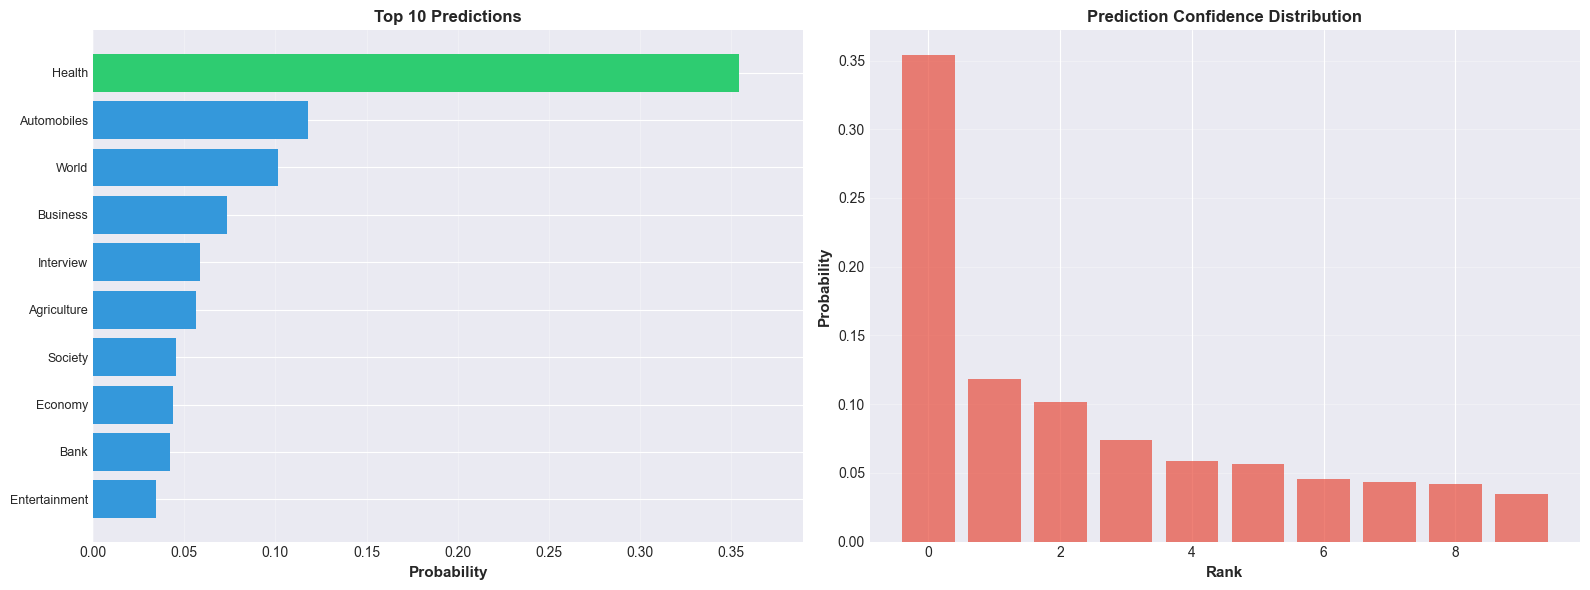

✓ Inference visualization saved

Sample Text: ÿþ$ M 0 ? 6 B 2 @   2 M  @...
Predicted: Health (Confidence: 35.42%)


In [15]:
# Visualize predictions for a sample text
sample_text = test_df.iloc[0]['text']
result = predict_text(sample_text, model, tokenizer, id_to_label, device, top_k=10)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 predictions bar chart
top_10 = result['top_k_predictions'][:10]
labels = [pred['label'] for pred in top_10]
probs = [pred['probability'] for pred in top_10]

colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(labels))]
ax1.barh(range(len(labels)), probs, color=colors)
ax1.set_yticks(range(len(labels)))
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_xlabel('Probability', fontsize=11, fontweight='bold')
ax1.set_title('Top 10 Predictions', fontsize=12, fontweight='bold')
ax1.set_xlim([0, max(probs) * 1.1])
ax1.grid(True, alpha=0.3, axis='x')
ax1.invert_yaxis()

# Confidence distribution
all_probs = [pred['probability'] for pred in result['top_k_predictions']]
ax2.bar(range(len(all_probs)), all_probs, color='#e74c3c', alpha=0.7)
ax2.set_xlabel('Rank', fontsize=11, fontweight='bold')
ax2.set_ylabel('Probability', fontsize=11, fontweight='bold')
ax2.set_title('Prediction Confidence Distribution', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(viz_dir / 'inference_example.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Inference visualization saved")
print(f"\nSample Text: {sample_text[:150]}...")
print(f"Predicted: {result['predicted_class']} (Confidence: {result['confidence']*100:.2f}%)")


### 11.4. Interactive Inference Function

You can use this function to make predictions on any text input.


In [16]:
# Interactive inference - modify the text below to test your own samples
def interactive_predict(text_input):
    """
    Interactive function to predict category for any text.
    Just call this function with your text string.
    """
    result = predict_text(text_input, model, tokenizer, id_to_label, device, top_k=5)
    
    print("=" * 80)
    print("PREDICTION RESULT")
    print("=" * 80)
    print(f"Input Text: {text_input[:200]}{'...' if len(text_input) > 200 else ''}")
    print(f"\nPredicted Category: {result['predicted_class']}")
    print(f"Confidence: {result['confidence']:.4f} ({result['confidence']*100:.2f}%)")
    print(f"\nTop 5 Predictions:")
    print("-" * 80)
    for i, pred in enumerate(result['top_k_predictions'], 1):
        print(f"{i}. {pred['label']:<25} {pred['confidence_percent']:>6.2f}%")
    print("=" * 80)
    
    return result

# Example usage:
# Uncomment and modify the text below to test your own samples
# interactive_predict("Your Nepali text here...")

print("✓ Interactive inference function ready")
print("\nTo use: interactive_predict('Your Nepali text here...')")


✓ Interactive inference function ready

To use: interactive_predict('Your Nepali text here...')


## 12. Save Evaluation Results


In [ ]:
# Create evaluation summary
evaluation_summary = {
    'model_name': MODEL_NAME,
    'num_classes': NUM_CLASSES,
    'test_samples': len(test_df),
    'accuracy': float(accuracy),
    'precision_weighted': float(precision_weighted),
    'precision_macro': float(precision_macro),
    'recall_weighted': float(recall_weighted),
    'recall_macro': float(recall_macro),
    'f1_weighted': float(f1_weighted),
    'f1_macro': float(f1_macro),
    'misclassified_samples': int(len(misclassified_indices)),
    'error_rate': float(len(misclassified_indices) / len(all_labels)),
    'per_class_metrics': {
        str(i): {
            'label': metrics['label'],
            'support': metrics['support'],
            'precision': float(metrics['precision']),
            'recall': float(metrics['recall']),
            'f1': float(metrics['f1'])
        }
        for i, metrics in per_class_metrics.items()
    }
}

# Save as JSON
results_dir = project_root / 'results'
results_dir.mkdir(exist_ok=True)

evaluation_json_path = results_dir / 'test_evaluation.json'
with open(evaluation_json_path, 'w', encoding='utf-8') as f:
    json.dump(evaluation_summary, f, indent=2, ensure_ascii=False)
print(f"✓ Evaluation results (JSON) saved to {evaluation_json_path}")

# Save as readable text file
evaluation_txt_path = results_dir / 'test_evaluation.txt'
with open(evaluation_txt_path, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("NEPALI NEWS CLASSIFICATION - TEST SET EVALUATION\n")
    f.write("=" * 80 + "\n\n")
    
    f.write("MODEL INFORMATION\n")
    f.write("-" * 80 + "\n")
    f.write(f"Model Name: {MODEL_NAME}\n")
    f.write(f"Number of Classes: {NUM_CLASSES}\n")
    f.write(f"Test Samples: {len(test_df):,}\n\n")
    
    f.write("OVERALL METRICS\n")
    f.write("-" * 80 + "\n")
    f.write(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n\n")
    
    f.write("Weighted Average Metrics:\n")
    f.write(f"  Precision: {precision_weighted:.4f}\n")
    f.write(f"  Recall:    {recall_weighted:.4f}\n")
    f.write(f"  F1 Score:  {f1_weighted:.4f}\n\n")
    
    f.write("Macro Average Metrics:\n")
    f.write(f"  Precision: {precision_macro:.4f}\n")
    f.write(f"  Recall:    {recall_macro:.4f}\n")
    f.write(f"  F1 Score:  {f1_macro:.4f}\n\n")
    
    f.write("ERROR ANALYSIS\n")
    f.write("-" * 80 + "\n")
    f.write(f"Misclassified Samples: {len(misclassified_indices):,}\n")
    f.write(f"Error Rate: {len(misclassified_indices)/len(all_labels)*100:.2f}%\n\n")
    
    f.write("PER-CLASS METRICS\n")
    f.write("-" * 80 + "\n")
    f.write(f"{'Class ID':<10} {'Label':<25} {'Support':<10} {'Precision':<12} {'Recall':<12} {'F1':<12}\n")
    f.write("-" * 80 + "\n")
    for i in sorted(per_class_metrics.keys()):
        metrics = per_class_metrics[i]
        f.write(f"{i:<10} {metrics['label']:<25} {metrics['support']:<10} "
                f"{metrics['precision']:<12.4f} {metrics['recall']:<12.4f} {metrics['f1']:<12.4f}\n")
    
    f.write("\n" + "=" * 80 + "\n")
    f.write("END OF EVALUATION REPORT\n")
    f.write("=" * 80 + "\n")

print(f"✓ Evaluation results (TXT) saved to {evaluation_txt_path}")

# Print summary
print("\n" + "=" * 80)
print("EVALUATION SUMMARY")
print("=" * 80)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Test F1 (weighted): {f1_weighted:.4f}")
print(f"Test F1 (macro): {f1_macro:.4f}")
print(f"Misclassified: {len(misclassified_indices)}/{len(all_labels)} ({len(misclassified_indices)/len(all_labels)*100:.2f}%)")
print("=" * 80)


✓ Evaluation results (JSON) saved to d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\results\test_evaluation.json
✓ Evaluation results (TXT) saved to d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\results\test_evaluation.txt

EVALUATION SUMMARY
Test Accuracy: 0.6989 (69.89%)
Test F1 (weighted): 0.7136
Test F1 (macro): 0.6843
Misclassified: 315/1046 (30.11%)


: 